# Homework 6: CNN for Fashion MNIST

In this assignment I build and evaluate a convolutional neural network (CNN) for image classification on the Fashion MNIST dataset. I start with exploratory data analysis, then train a baseline CNN adapted from the May 19 in-class notebook (MNIST CNN architecture).

**Plan (later sections)**

1. EDA — inspect images, class balance, and pixel statistics.
2. Baseline CNN — simple Conv2D + MaxPooling + Dense stack.
3. Experiments — change one factor at a time to understand what helps.
4. Optuna search — systematic tuning for a stronger final model.
5. Final evaluation on the held-out test set and a personal workflow summary.

## 1. Imports

In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, callbacks
from tensorflow.keras.datasets import fashion_mnist

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

import optuna



# reproducibility
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

tf.get_logger().setLevel('ERROR')
optuna.logging.set_verbosity(optuna.logging.WARNING)

## 2. Load the data

Fashion MNIST contains 60,000 training and 10,000 test images of 28×28 grayscale clothing items across 10 classes.

In [2]:
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

CLASS_NAMES = [
    "T-shirt/top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot",
]

print("Training shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("Pixel dtype:", X_train.dtype)
print("Pixel range:", X_train.min(), "–", X_train.max())
print("Labels:", np.unique(y_train))

Training shape: (60000, 28, 28)
Test shape: (10000, 28, 28)
Pixel dtype: uint8
Pixel range: 0 – 255
Labels: [0 1 2 3 4 5 6 7 8 9]


## 3. Exploratory data analysis

Before modeling, I inspect what the images look like and how classes are distributed. Fashion MNIST is balanced by design, but verifying that helps catch loading or preprocessing mistakes early.

### 3.1 Class breakdown

In [3]:
train_counts = pd.Series(y_train).value_counts().sort_index()
test_counts = pd.Series(y_test).value_counts().sort_index()

class_df = pd.DataFrame({
    "class_id": train_counts.index,
    "class_name": [CLASS_NAMES[i] for i in train_counts.index],
    "train_count": train_counts.values,
    "test_count": test_counts.values,
})
class_df["train_pct"] = (class_df["train_count"] / len(y_train) * 100).round(1)
class_df["test_pct"] = (class_df["test_count"] / len(y_test) * 100).round(1)

class_df

,class_id,class_name,train_count,test_count,train_pct,test_pct
0,0,T-shirt/top,6000,1000,10.0,10.0
1,1,Trouser,6000,1000,10.0,10.0
2,2,Pullover,6000,1000,10.0,10.0
3,3,Dress,6000,1000,10.0,10.0
4,4,Coat,6000,1000,10.0,10.0
5,5,Sandal,6000,1000,10.0,10.0
6,6,Shirt,6000,1000,10.0,10.0
7,7,Sneaker,6000,1000,10.0,10.0
8,8,Bag,6000,1000,10.0,10.0
9,9,Ankle boot,6000,1000,10.0,10.0


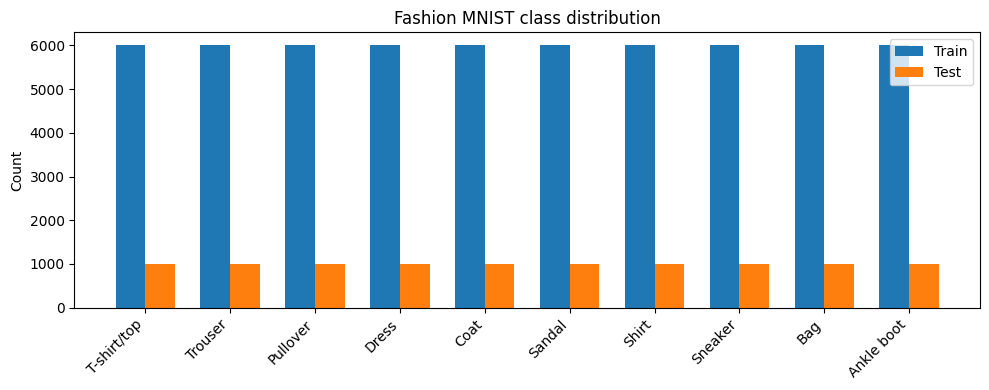

In [4]:
fig, ax = plt.subplots(figsize=(10, 4))
x = np.arange(len(CLASS_NAMES))
width = 0.35

ax.bar(x - width / 2, class_df["train_count"], width, label="Train")
ax.bar(x + width / 2, class_df["test_count"], width, label="Test")
ax.set_xticks(x)
ax.set_xticklabels(CLASS_NAMES, rotation=45, ha="right")
ax.set_ylabel("Count")
ax.set_title("Fashion MNIST class distribution")
ax.legend()
plt.tight_layout()
plt.show()

### 3.2 Sample images

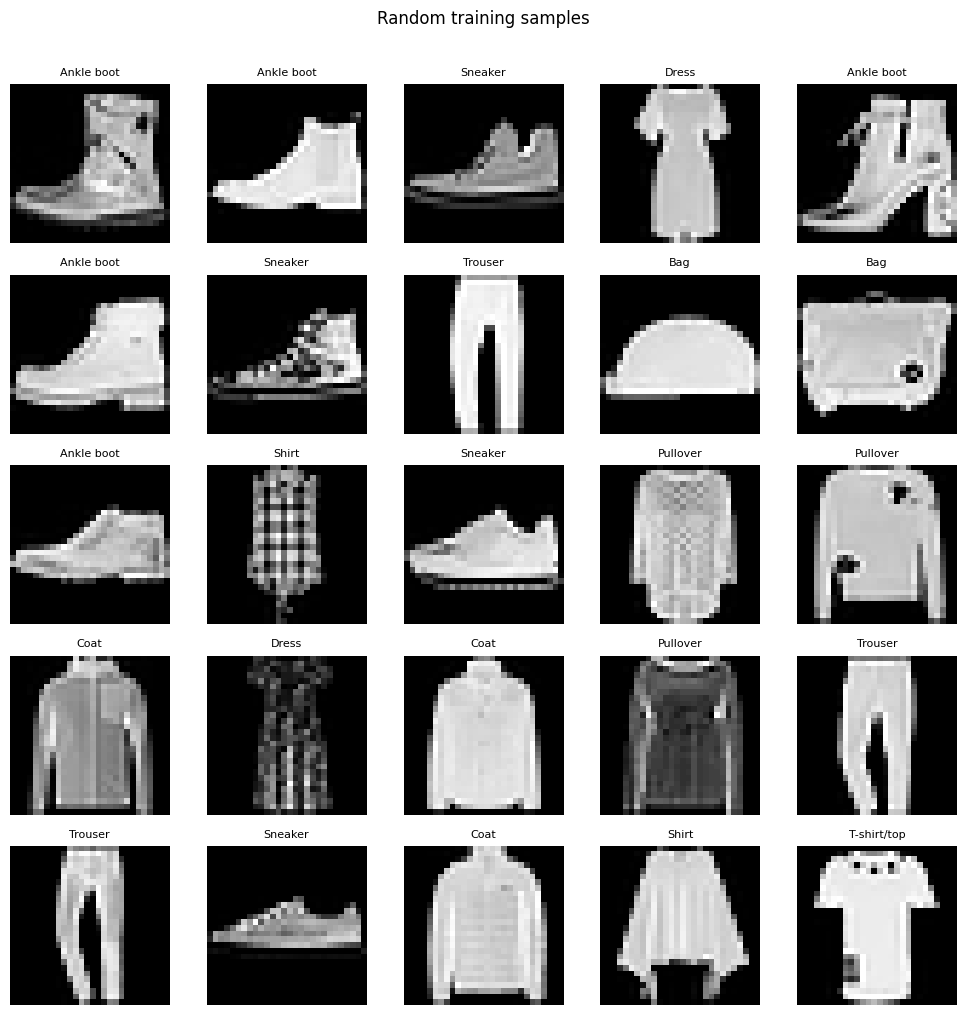

In [5]:
# random grid of 25 training images
rng = np.random.default_rng(SEED)
sample_idx = rng.choice(len(X_train), size=25, replace=False)

plt.figure(figsize=(10, 10))
for i, idx in enumerate(sample_idx):
    plt.subplot(5, 5, i + 1)
    plt.imshow(X_train[idx], cmap="gray")
    plt.title(CLASS_NAMES[y_train[idx]], fontsize=8)
    plt.axis("off")
plt.suptitle("Random training samples", y=1.01)
plt.tight_layout()
plt.show()

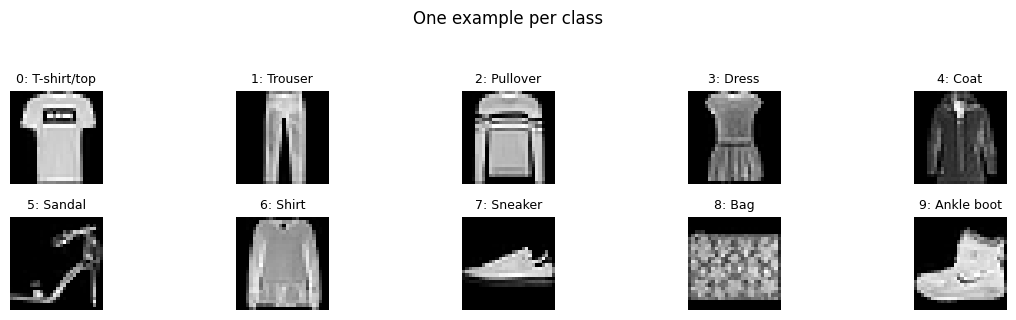

In [6]:
# one example per class
plt.figure(figsize=(12, 3))
for class_id in range(10):
    idx = np.where(y_train == class_id)[0][0]
    plt.subplot(2, 5, class_id + 1)
    plt.imshow(X_train[idx], cmap="gray")
    plt.title(f"{class_id}: {CLASS_NAMES[class_id]}", fontsize=9)
    plt.axis("off")
plt.suptitle("One example per class", y=1.05)
plt.tight_layout()
plt.show()

### 3.3 Pixel intensity distribution

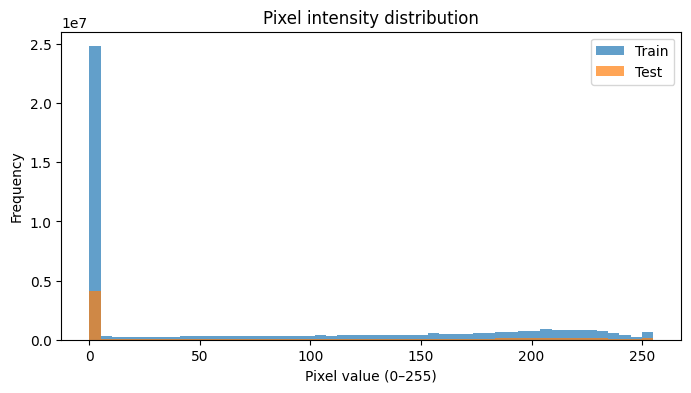

Train mean pixel: 72.94
Test mean pixel:  73.15


In [7]:
plt.figure(figsize=(8, 4))
plt.hist(X_train.ravel(), bins=50, alpha=0.7, label="Train")
plt.hist(X_test.ravel(), bins=50, alpha=0.7, label="Test")
plt.xlabel("Pixel value (0–255)")
plt.ylabel("Frequency")
plt.title("Pixel intensity distribution")
plt.legend()
plt.show()

print(f"Train mean pixel: {X_train.mean():.2f}")
print(f"Test mean pixel:  {X_test.mean():.2f}")

**EDA takeaways:** Images are 28×28 grayscale with pixel values in [0, 255]. All 10 classes are evenly represented (~6,000 train / ~1,000 test each). Most pixels are dark (background), with brighter values on the clothing outline — normalization to [0, 1] will be important for stable training.

## 4. Preprocessing for CNN

Following the in-class MNIST notebook: scale pixels to [0, 1] and add a channel dimension so Keras receives shape `(28, 28, 1)`.

In [8]:
X_train_norm = X_train.astype("float32") / 255.0
X_test_norm = X_test.astype("float32") / 255.0

X_train_cnn = X_train_norm[..., np.newaxis]
X_test_cnn = X_test_norm[..., np.newaxis]

print("CNN input shape:", X_train_cnn.shape)

CNN input shape: (60000, 28, 28, 1)


## 5. Baseline CNN

This is the same simple architecture from the May 19 in-class notebook: one convolutional block (32 filters, 3×3), max pooling, flatten, one dense hidden layer, and a 10-class softmax output.

In [9]:
baseline_cnn = models.Sequential([
    layers.Input(shape=(28, 28, 1)),
    layers.Conv2D(32, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(64, activation="relu"),
    layers.Dense(10, activation="softmax"),
])

baseline_cnn.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

baseline_cnn.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 5408)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       346,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 347,146 (1.32 MB)

 Trainable params: 347,146 (1.32 MB)

 Non-trainable params: 0 (0.00 B)

In [10]:
EPOCHS = 10
BATCH_SIZE = 128
VAL_SPLIT = 0.1

baseline_history = baseline_cnn.fit(
    X_train_cnn,
    y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=VAL_SPLIT,
    verbose=1,
)

Epoch 1/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.8353 - loss: 0.4759 - val_accuracy: 0.8777 - val_loss: 0.3384
Epoch 2/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.8892 - loss: 0.3114 - val_accuracy: 0.8978 - val_loss: 0.2864
Epoch 3/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9026 - loss: 0.2701 - val_accuracy: 0.9040 - val_loss: 0.2666
Epoch 4/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9129 - loss: 0.2426 - val_accuracy: 0.9070 - val_loss: 0.2574
Epoch 5/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9205 - loss: 0.2212 - val_accuracy: 0.9098 - val_loss: 0.2525
Epoch 6/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9263 - loss: 0.2036 - val_accuracy: 0.9123 - val_loss: 0.2486
Epoch 7/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9326 - loss: 0.1879 - val_accuracy: 0.9133 - val_loss: 0.2468
Epoch 8/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9378 - loss: 0.1742 - val_accuracy: 0

## 6. Baseline evaluation

In [11]:
baseline_test_loss, baseline_test_acc = baseline_cnn.evaluate(
    X_test_cnn, y_test, verbose=0
)
print(f"Baseline CNN test accuracy: {baseline_test_acc:.4f}")
print(f"Baseline CNN test loss:     {baseline_test_loss:.4f}")

Baseline CNN test accuracy: 0.9121
Baseline CNN test loss:     0.2647


In [12]:
y_pred = np.argmax(baseline_cnn.predict(X_test_cnn, verbose=0), axis=1)

print(classification_report(y_test, y_pred, target_names=CLASS_NAMES))

              precision    recall  f1-score   support

 T-shirt/top       0.87      0.85      0.86      1000
     Trouser       0.99      0.98      0.99      1000
    Pullover       0.87      0.88      0.88      1000
       Dress       0.92      0.91      0.91      1000
        Coat       0.83      0.91      0.87      1000
      Sandal       0.96      0.99      0.97      1000
       Shirt       0.78      0.71      0.75      1000
     Sneaker       0.96      0.96      0.96      1000
         Bag       0.96      0.98      0.97      1000
  Ankle boot       0.98      0.95      0.96      1000

    accuracy                           0.91     10000
   macro avg       0.91      0.91      0.91     10000
weighted avg       0.91      0.91      0.91     10000



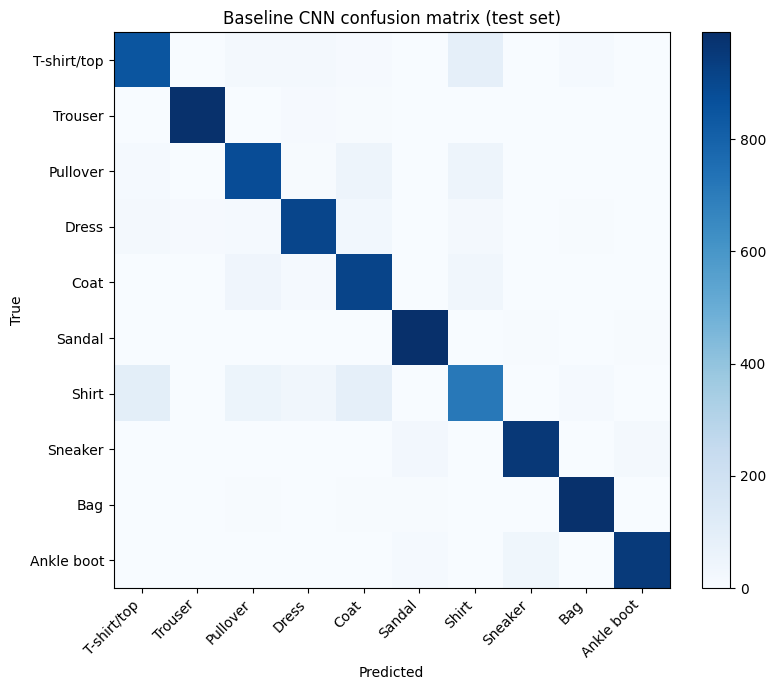

In [13]:
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks(range(10))
ax.set_yticks(range(10))
ax.set_xticklabels(CLASS_NAMES, rotation=45, ha="right")
ax.set_yticklabels(CLASS_NAMES)
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_title("Baseline CNN confusion matrix (test set)")
plt.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout()
plt.show()

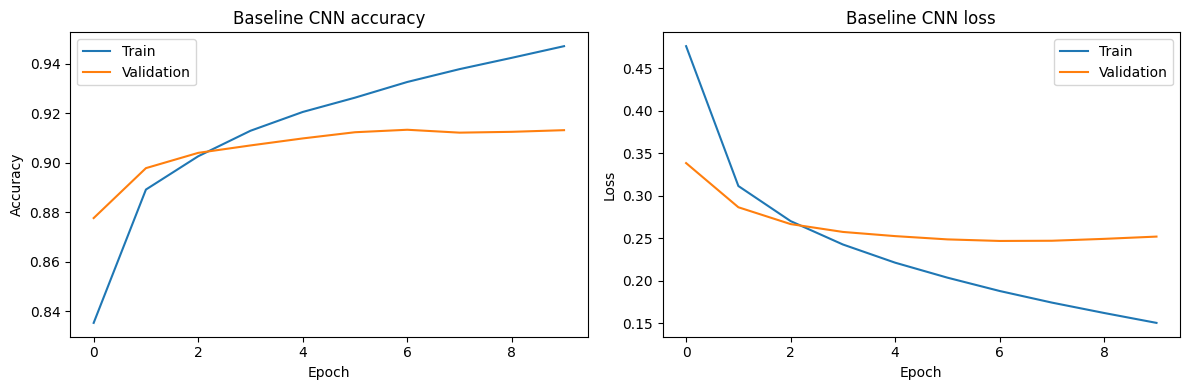

In [14]:
history = baseline_history.history

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history["accuracy"], label="Train")
axes[0].plot(history["val_accuracy"], label="Validation")
axes[0].set_title("Baseline CNN accuracy")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].legend()

axes[1].plot(history["loss"], label="Train")
axes[1].plot(history["val_loss"], label="Validation")
axes[1].set_title("Baseline CNN loss")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].legend()

plt.tight_layout()
plt.show()

## 7. Experiment 1 — Baseline CNN + data augmentation (horizontal flip + rotation)

In this experiment I keep the baseline architecture the same and change one factor: training-time image augmentation.

- `RandomFlip("horizontal")`
- `RandomRotation(0.1)`

This helps test whether geometric variation improves generalization.

In [15]:
aug_cnn = models.Sequential([
    layers.Input(shape=(28, 28, 1)),
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.Conv2D(32, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(64, activation="relu"),
    layers.Dense(10, activation="softmax"),
])

aug_cnn.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

aug_history = aug_cnn.fit(
    X_train_cnn,
    y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=VAL_SPLIT,
    verbose=1,
)

aug_test_loss, aug_test_acc = aug_cnn.evaluate(X_test_cnn, y_test, verbose=0)
print(f"Augmented CNN test accuracy: {aug_test_acc:.4f}")
print(f"Augmented CNN test loss:     {aug_test_loss:.4f}")

Epoch 1/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.7396 - loss: 0.7299 - val_accuracy: 0.8017 - val_loss: 0.5536
Epoch 2/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.8194 - loss: 0.5025 - val_accuracy: 0.8318 - val_loss: 0.4704
Epoch 3/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.8376 - loss: 0.4494 - val_accuracy: 0.8437 - val_loss: 0.4290
Epoch 4/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.8483 - loss: 0.4169 - val_accuracy: 0.8508 - val_loss: 0.4099
Epoch 5/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.8564 - loss: 0.3968 - val_accuracy: 0.8558 - val_loss: 0.3976
Epoch 6/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.8634 - loss: 0.3792 - val_accuracy: 0.8598 - val_loss: 0.3930
Epoch 7/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.8668 - loss: 0.3664 - val_accuracy: 0.8622 - val_loss: 0.3694
Epoch 8/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.8716 - loss: 0.3538 - val_accuracy:

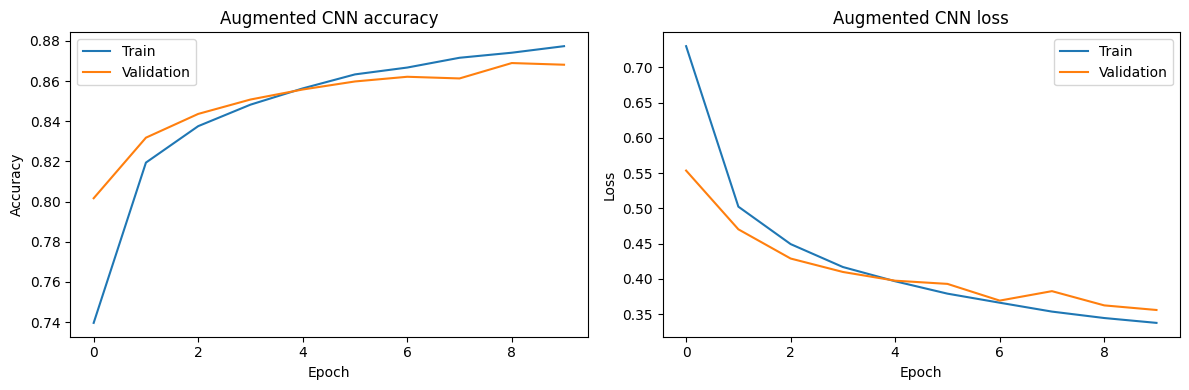

In [16]:
aug_h = aug_history.history

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(aug_h["accuracy"], label="Train")
axes[0].plot(aug_h["val_accuracy"], label="Validation")
axes[0].set_title("Augmented CNN accuracy")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].legend()

axes[1].plot(aug_h["loss"], label="Train")
axes[1].plot(aug_h["val_loss"], label="Validation")
axes[1].set_title("Augmented CNN loss")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].legend()

plt.tight_layout()
plt.show()

## 8. Experiment 2 — Deeper CNN (add a second convolution block)

In this experiment I keep preprocessing and training settings the same as baseline and change one factor: model depth.

- Add `Conv2D(64, 3x3)` + `MaxPooling2D(2x2)` before flattening.

In [17]:
deep_cnn = models.Sequential([
    layers.Input(shape=(28, 28, 1)),
    layers.Conv2D(32, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(64, activation="relu"),
    layers.Dense(10, activation="softmax"),
])

deep_cnn.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

deep_history = deep_cnn.fit(
    X_train_cnn,
    y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=VAL_SPLIT,
    verbose=1,
)

deep_test_loss, deep_test_acc = deep_cnn.evaluate(X_test_cnn, y_test, verbose=0)
print(f"Deeper CNN test accuracy: {deep_test_acc:.4f}")
print(f"Deeper CNN test loss:     {deep_test_loss:.4f}")

Epoch 1/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - accuracy: 0.7833 - loss: 0.5947 - val_accuracy: 0.8520 - val_loss: 0.4229
Epoch 2/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - accuracy: 0.8663 - loss: 0.3715 - val_accuracy: 0.8730 - val_loss: 0.3587
Epoch 3/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - accuracy: 0.8820 - loss: 0.3236 - val_accuracy: 0.8870 - val_loss: 0.3124
Epoch 4/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 7s 17ms/step - accuracy: 0.8924 - loss: 0.2933 - val_accuracy: 0.8955 - val_loss: 0.2889
Epoch 5/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 7s 17ms/step - accuracy: 0.9005 - loss: 0.2704 - val_accuracy: 0.9022 - val_loss: 0.2745
Epoch 6/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - accuracy: 0.9086 - loss: 0.2511 - val_accuracy: 0.9047 - val_loss: 0.2652
Epoch 7/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - accuracy: 0.9140 - loss: 0.2346 - val_accuracy: 0.9062 - val_loss: 0.2603
Epoch 8/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 8s 19ms/step - accuracy: 0.9200 - loss: 0.2196 - val_accu

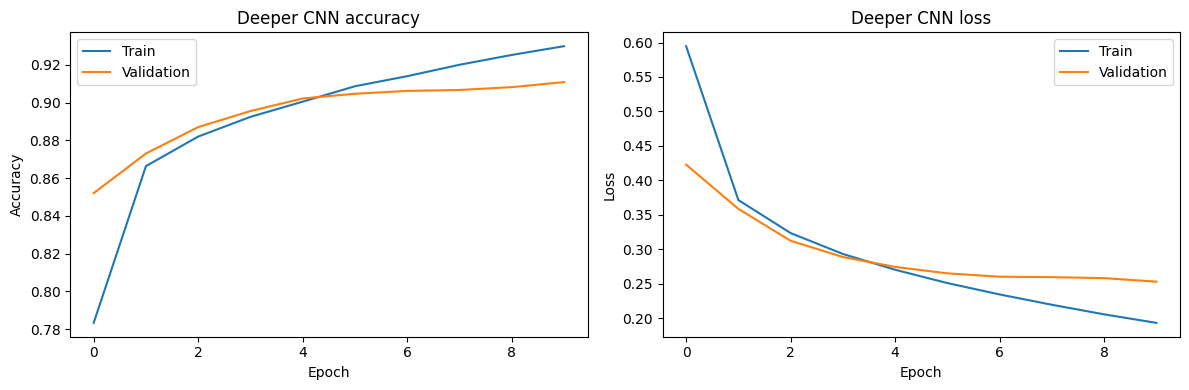

In [18]:
deep_h = deep_history.history

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(deep_h["accuracy"], label="Train")
axes[0].plot(deep_h["val_accuracy"], label="Validation")
axes[0].set_title("Deeper CNN accuracy")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].legend()

axes[1].plot(deep_h["loss"], label="Train")
axes[1].plot(deep_h["val_loss"], label="Validation")
axes[1].set_title("Deeper CNN loss")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].legend()

plt.tight_layout()
plt.show()

## 9. Side-by-side comparison: baseline vs augmented vs deeper

In [19]:
results = pd.DataFrame({
    "model": ["Baseline CNN", "Augmented CNN", "Deeper CNN"],
    "test_accuracy": [baseline_test_acc, aug_test_acc, deep_test_acc],
    "test_loss": [baseline_test_loss, aug_test_loss, deep_test_loss],
})

results = results.sort_values("test_accuracy", ascending=False).reset_index(drop=True)
results

,model,test_accuracy,test_loss
0,Baseline CNN,0.9121,0.264735
1,Deeper CNN,0.9062,0.268204
2,Augmented CNN,0.8685,0.379697


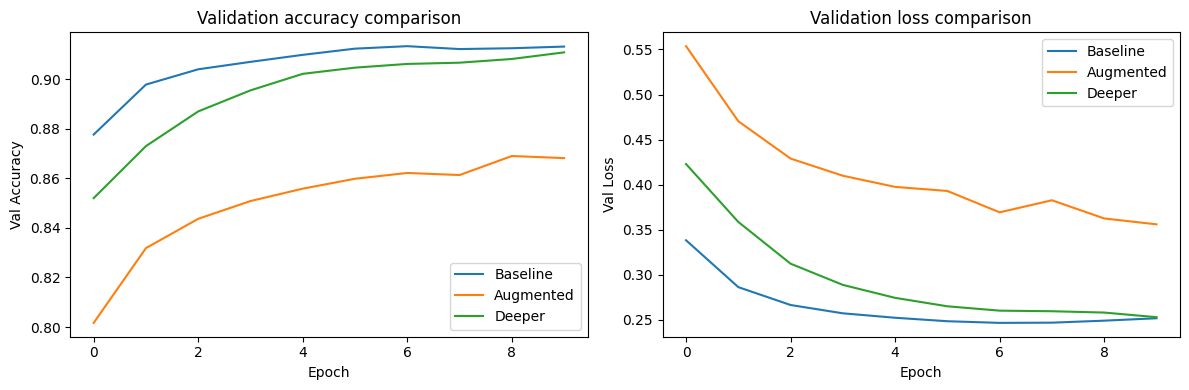

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Accuracy comparison
axes[0].plot(baseline_history.history["val_accuracy"], label="Baseline")
axes[0].plot(aug_history.history["val_accuracy"], label="Augmented")
axes[0].plot(deep_history.history["val_accuracy"], label="Deeper")
axes[0].set_title("Validation accuracy comparison")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Val Accuracy")
axes[0].legend()

# Loss comparison
axes[1].plot(baseline_history.history["val_loss"], label="Baseline")
axes[1].plot(aug_history.history["val_loss"], label="Augmented")
axes[1].plot(deep_history.history["val_loss"], label="Deeper")
axes[1].set_title("Validation loss comparison")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Val Loss")
axes[1].legend()

plt.tight_layout()
plt.show()

## 10. Experiment 3 — Hard-example mining CNN

In this experiment I keep the baseline architecture and optimizer settings, then do a second training pass that upweights difficult upper-body cases.

Hard examples are defined as **misclassified training samples** from upper-body classes:

- `T-shirt/top`, `Pullover`, `Dress`, `Coat`, `Shirt` (class ids: 0, 2, 3, 4, 6)

This targets the confusion pattern seen in the confusion matrices.

In [21]:
UPPER_BODY_CLASSES = [0, 2, 3, 4, 6]

hard_cnn = models.Sequential([
    layers.Input(shape=(28, 28, 1)),
    layers.Conv2D(32, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(64, activation="relu"),
    layers.Dense(10, activation="softmax"),
])

hard_cnn.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

# Pass 1: normal training
hard_history_pass1 = hard_cnn.fit(
    X_train_cnn,
    y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=VAL_SPLIT,
    verbose=1,
)

# Identify hard examples from upper-body classes
train_pred = np.argmax(hard_cnn.predict(X_train_cnn, verbose=0), axis=1)
upper_mask = np.isin(y_train, UPPER_BODY_CLASSES)
hard_idx = np.where((train_pred != y_train) & upper_mask)[0]

print(f"Hard upper-body examples found: {len(hard_idx)}")

# Pass 2: upweight hard examples by duplicating them
if len(hard_idx) > 0:
    X_train_hard = np.concatenate(
        [X_train_cnn, X_train_cnn[hard_idx], X_train_cnn[hard_idx]], axis=0
    )
    y_train_hard = np.concatenate(
        [y_train, y_train[hard_idx], y_train[hard_idx]], axis=0
    )

    hard_history_pass2 = hard_cnn.fit(
        X_train_hard,
        y_train_hard,
        epochs=3,
        batch_size=BATCH_SIZE,
        validation_split=VAL_SPLIT,
        verbose=1,
    )

hard_test_loss, hard_test_acc = hard_cnn.evaluate(X_test_cnn, y_test, verbose=0)
print(f"Hard-example mining CNN test accuracy: {hard_test_acc:.4f}")
print(f"Hard-example mining CNN test loss:     {hard_test_loss:.4f}")

Epoch 1/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.8238 - loss: 0.5001 - val_accuracy: 0.8750 - val_loss: 0.3563
Epoch 2/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.8812 - loss: 0.3346 - val_accuracy: 0.8898 - val_loss: 0.3109
Epoch 3/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.8954 - loss: 0.2932 - val_accuracy: 0.9008 - val_loss: 0.2854
Epoch 4/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9071 - loss: 0.2636 - val_accuracy: 0.8995 - val_loss: 0.2775
Epoch 5/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9131 - loss: 0.2420 - val_accuracy: 0.9003 - val_loss: 0.2697
Epoch 6/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9197 - loss: 0.2237 - val_accuracy: 0.9037 - val_loss: 0.2635
Epoch 7/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.9258 - loss: 0.2073 - val_accuracy: 0.9057 - val_loss: 0.2605
Epoch 8/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9316 - loss: 0.1925 - val_accuracy: 0

In [22]:
y_pred_hard = np.argmax(hard_cnn.predict(X_test_cnn, verbose=0), axis=1)
print(classification_report(y_test, y_pred_hard, target_names=CLASS_NAMES))

              precision    recall  f1-score   support

 T-shirt/top       0.87      0.85      0.86      1000
     Trouser       1.00      0.97      0.99      1000
    Pullover       0.86      0.86      0.86      1000
       Dress       0.89      0.94      0.91      1000
        Coat       0.83      0.88      0.86      1000
      Sandal       0.97      0.98      0.98      1000
       Shirt       0.79      0.72      0.75      1000
     Sneaker       0.96      0.96      0.96      1000
         Bag       0.97      0.98      0.98      1000
  Ankle boot       0.97      0.96      0.97      1000

    accuracy                           0.91     10000
   macro avg       0.91      0.91      0.91     10000
weighted avg       0.91      0.91      0.91     10000



## 11. Updated comparison: baseline + experiments 1/2/3

In [23]:
results_exp = pd.DataFrame({
    "model": [
        "Baseline CNN",
        "Experiment 1: Augmented CNN",
        "Experiment 2: Deeper CNN",
        "Experiment 3: Hard-Example Mining CNN",
    ],
    "test_accuracy": [baseline_test_acc, aug_test_acc, deep_test_acc, hard_test_acc],
    "test_loss": [baseline_test_loss, aug_test_loss, deep_test_loss, hard_test_loss],
})

results_exp = results_exp.sort_values("test_accuracy", ascending=False).reset_index(drop=True)
results_exp

,model,test_accuracy,test_loss
0,Baseline CNN,0.9121,0.264735
1,Experiment 3: Hard-Example Mining CNN,0.9116,0.264742
2,Experiment 2: Deeper CNN,0.9062,0.268204
3,Experiment 1: Augmented CNN,0.8685,0.379697


## 12. Multi-seed stability test (baseline + experiments 1/2/3)

To reduce the chance that one train/validation split or initialization is lucky, this section trains each model with multiple random seeds and compares mean ± std test metrics.

> Note: this can take a while to run.

In [24]:
SEEDS = [11, 22, 33, 44, 55]
EPOCHS_SEED = 6


def build_baseline_seed_model(seed):
    tf.keras.utils.set_random_seed(seed)
    return models.Sequential([
        layers.Input(shape=(28, 28, 1)),
        layers.Conv2D(32, (3, 3), activation="relu"),
        layers.MaxPooling2D((2, 2)),
        layers.Flatten(),
        layers.Dense(64, activation="relu"),
        layers.Dense(10, activation="softmax"),
    ])


def build_aug_seed_model(seed):
    tf.keras.utils.set_random_seed(seed)
    return models.Sequential([
        layers.Input(shape=(28, 28, 1)),
        layers.RandomFlip("horizontal", seed=seed),
        layers.RandomRotation(0.1, seed=seed),
        layers.Conv2D(32, (3, 3), activation="relu"),
        layers.MaxPooling2D((2, 2)),
        layers.Flatten(),
        layers.Dense(64, activation="relu"),
        layers.Dense(10, activation="softmax"),
    ])


def build_deep_seed_model(seed):
    tf.keras.utils.set_random_seed(seed)
    return models.Sequential([
        layers.Input(shape=(28, 28, 1)),
        layers.Conv2D(32, (3, 3), activation="relu"),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(64, (3, 3), activation="relu"),
        layers.MaxPooling2D((2, 2)),
        layers.Flatten(),
        layers.Dense(64, activation="relu"),
        layers.Dense(10, activation="softmax"),
    ])


def train_eval_sparse(model, x_train, y_train, x_test, y_test, epochs=6, batch_size=128):
    model.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    model.fit(
        x_train,
        y_train,
        epochs=epochs,
        batch_size=batch_size,
        validation_split=0.1,
        verbose=0,
    )
    test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
    y_pred = np.argmax(model.predict(x_test, verbose=0), axis=1)
    rep = classification_report(y_test, y_pred, output_dict=True, target_names=CLASS_NAMES)
    return {
        "test_accuracy": test_acc,
        "test_loss": test_loss,
        "shirt_f1": rep["Shirt"]["f1-score"],
        "shirt_recall": rep["Shirt"]["recall"],
    }


def train_eval_hard_example(seed, x_train, y_train, x_test, y_test, epochs=6, batch_size=128):
    model = build_baseline_seed_model(seed)
    model.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    # pass 1
    model.fit(
        x_train,
        y_train,
        epochs=epochs,
        batch_size=batch_size,
        validation_split=0.1,
        verbose=0,
    )

    pred_train = np.argmax(model.predict(x_train, verbose=0), axis=1)
    upper_mask = np.isin(y_train, UPPER_BODY_CLASSES)
    hard_idx_seed = np.where((pred_train != y_train) & upper_mask)[0]

    if len(hard_idx_seed) > 0:
        x_h = np.concatenate([x_train, x_train[hard_idx_seed], x_train[hard_idx_seed]], axis=0)
        y_h = np.concatenate([y_train, y_train[hard_idx_seed], y_train[hard_idx_seed]], axis=0)
        model.fit(
            x_h,
            y_h,
            epochs=3,
            batch_size=batch_size,
            validation_split=0.1,
            verbose=0,
        )

    test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
    y_pred = np.argmax(model.predict(x_test, verbose=0), axis=1)
    rep = classification_report(y_test, y_pred, output_dict=True, target_names=CLASS_NAMES)
    return {
        "test_accuracy": test_acc,
        "test_loss": test_loss,
        "shirt_f1": rep["Shirt"]["f1-score"],
        "shirt_recall": rep["Shirt"]["recall"],
    }


seed_rows = []

for seed in SEEDS:
    tf.keras.backend.clear_session()

    # Baseline
    base_model = build_baseline_seed_model(seed)
    base_metrics = train_eval_sparse(
        base_model, X_train_cnn, y_train, X_test_cnn, y_test,
        epochs=EPOCHS_SEED, batch_size=BATCH_SIZE
    )
    seed_rows.append({"seed": seed, "model": "Baseline CNN", **base_metrics})

    # Experiment 1: Augmented
    tf.keras.backend.clear_session()
    aug_model_seed = build_aug_seed_model(seed)
    aug_metrics_seed = train_eval_sparse(
        aug_model_seed, X_train_cnn, y_train, X_test_cnn, y_test,
        epochs=EPOCHS_SEED, batch_size=BATCH_SIZE
    )
    seed_rows.append({"seed": seed, "model": "Experiment 1: Augmented CNN", **aug_metrics_seed})

    # Experiment 2: Deeper
    tf.keras.backend.clear_session()
    deep_model_seed = build_deep_seed_model(seed)
    deep_metrics_seed = train_eval_sparse(
        deep_model_seed, X_train_cnn, y_train, X_test_cnn, y_test,
        epochs=EPOCHS_SEED, batch_size=BATCH_SIZE
    )
    seed_rows.append({"seed": seed, "model": "Experiment 2: Deeper CNN", **deep_metrics_seed})

    # Experiment 3: Hard-example mining
    tf.keras.backend.clear_session()
    hard_metrics_seed = train_eval_hard_example(
        seed, X_train_cnn, y_train, X_test_cnn, y_test,
        epochs=EPOCHS_SEED, batch_size=BATCH_SIZE
    )
    seed_rows.append({"seed": seed, "model": "Experiment 3: Hard-Example Mining CNN", **hard_metrics_seed})

seed_results = pd.DataFrame(seed_rows)
seed_results.head(12)

,seed,model,test_accuracy,test_loss,shirt_f1,shirt_recall
0,11,Baseline CNN,0.8990,0.274898,0.714218,0.751
1,11,Experiment 1: Augmented CNN,0.8564,0.410339,0.637760,0.706
2,11,Experiment 2: Deeper CNN,0.8917,0.293681,0.702095,0.687
3,11,Experiment 3: Hard-Example Mining CNN,0.8985,0.283639,0.745667,0.796
4,22,Baseline CNN,0.8998,0.272259,0.717485,0.753
5,22,Experiment 1: Augmented CNN,0.8568,0.417556,0.630058,0.654
6,22,Experiment 2: Deeper CNN,0.8928,0.293888,0.696004,0.688
7,22,Experiment 3: Hard-Example Mining CNN,0.9070,0.262441,0.745247,0.686
8,33,Baseline CNN,0.8983,0.276944,0.714809,0.683
9,33,Experiment 1: Augmented CNN,0.8621,0.404489,0.639428,0.626


In [25]:
summary = (
    seed_results
    .groupby("model")
    .agg(
        acc_mean=("test_accuracy", "mean"),
        acc_std=("test_accuracy", "std"),
        loss_mean=("test_loss", "mean"),
        loss_std=("test_loss", "std"),
        shirt_f1_mean=("shirt_f1", "mean"),
        shirt_f1_std=("shirt_f1", "std"),
        shirt_recall_mean=("shirt_recall", "mean"),
        shirt_recall_std=("shirt_recall", "std"),
    )
    .reset_index()
    .sort_values("acc_mean", ascending=False)
)

summary

,model,acc_mean,acc_std,loss_mean,loss_std,shirt_f1_mean,shirt_f1_std,shirt_recall_mean,shirt_recall_std
3,Experiment 3: Hard-Example Mining CNN,0.90604,0.004333,0.265901,0.010474,0.736682,0.010226,0.7104,0.067144
0,Baseline CNN,0.89990,0.002194,0.275775,0.004570,0.717610,0.003319,0.7164,0.033716
2,Experiment 2: Deeper CNN,0.89312,0.005322,0.295942,0.012679,0.695832,0.004438,0.6758,0.018185
1,Experiment 1: Augmented CNN,0.85772,0.003990,0.413986,0.010557,0.630941,0.008668,0.6424,0.055788


In [26]:
# How often each experiment beats baseline on test accuracy (paired by seed)
base_by_seed = seed_results[seed_results["model"] == "Baseline CNN"][["seed", "test_accuracy"]]

win_rows = []
for model_name in [
    "Experiment 1: Augmented CNN",
    "Experiment 2: Deeper CNN",
    "Experiment 3: Hard-Example Mining CNN",
]:
    m = seed_results[seed_results["model"] == model_name][["seed", "test_accuracy"]]
    merged = m.merge(base_by_seed, on="seed", suffixes=("_model", "_baseline"))
    wins = (merged["test_accuracy_model"] > merged["test_accuracy_baseline"]).sum()
    ties = (np.isclose(merged["test_accuracy_model"], merged["test_accuracy_baseline"]).sum())
    losses = len(merged) - wins - ties
    mean_delta = (merged["test_accuracy_model"] - merged["test_accuracy_baseline"]).mean()
    win_rows.append({
        "model": model_name,
        "wins_vs_baseline": wins,
        "ties_vs_baseline": ties,
        "losses_vs_baseline": losses,
        "mean_acc_delta_vs_baseline": mean_delta,
    })

pd.DataFrame(win_rows).sort_values("mean_acc_delta_vs_baseline", ascending=False)

,model,wins_vs_baseline,ties_vs_baseline,losses_vs_baseline,mean_acc_delta_vs_baseline
2,Experiment 3: Hard-Example Mining CNN,4,0,1,0.00614
1,Experiment 2: Deeper CNN,0,0,5,-0.00678
0,Experiment 1: Augmented CNN,0,0,5,-0.04218


## 13. Optuna tuning — final hard-example mining CNN

Experiment 3 (hard-example mining) performed best, so I use Optuna to tune its hyperparameters before building the final model.

Each trial:
1. Trains a CNN on a fixed train split.
2. Identifies misclassified upper-body training examples.
3. Fine-tunes with duplicated hard examples.
4. Returns validation accuracy (maximize).

Search space:
- Conv filter counts (1–2 blocks)
- Dense layer width
- Dropout rate
- Learning rate and batch size
- Pass-2 fine-tuning epochs

In [29]:
# Fixed train/val split for tuning (test set stays untouched)
X_tune_train, X_tune_val, y_tune_train, y_tune_val = train_test_split(
    X_train_cnn, y_train, test_size=VAL_SPLIT, random_state=SEED, stratify=y_train
)

print(f"Tuning train: {X_tune_train.shape[0]:,}  |  tuning val: {X_tune_val.shape[0]:,}")


def build_hard_mining_cnn(conv_f1, conv_f2, n_conv_blocks, dense_units, dropout):
    net = [
        layers.Input(shape=(28, 28, 1)),
        layers.Conv2D(conv_f1, (3, 3), activation="relu"),
        layers.MaxPooling2D((2, 2)),
    ]
    if n_conv_blocks == 2:
        net.extend([
            layers.Conv2D(conv_f2, (3, 3), activation="relu"),
            layers.MaxPooling2D((2, 2)),
        ])
    net.append(layers.Flatten())
    net.append(layers.Dense(dense_units, activation="relu"))
    if dropout > 0:
        net.append(layers.Dropout(dropout))
    net.append(layers.Dense(10, activation="softmax"))
    return models.Sequential(net)


def fit_hard_mining_model(
    params,
    x_train,
    y_train,
    x_val,
    y_val,
    seed=SEED,
    verbose=0,
):
    """Two-pass hard-example mining with a fixed validation set."""
    keras.utils.set_random_seed(seed)

    model = build_hard_mining_cnn(
        conv_f1=params["conv_f1"],
        conv_f2=params["conv_f2"],
        n_conv_blocks=params["n_conv_blocks"],
        dense_units=params["dense_units"],
        dropout=params["dropout"],
    )
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=params["lr"]),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )

    es = callbacks.EarlyStopping(
        monitor="val_loss", patience=3, restore_best_weights=True
    )

    # Pass 1
    model.fit(
        x_train,
        y_train,
        validation_data=(x_val, y_val),
        epochs=params.get("pass1_epochs", 12),
        batch_size=params["batch_size"],
        callbacks=[es],
        verbose=verbose,
    )

    # Pass 2: duplicate misclassified upper-body training examples
    train_pred = np.argmax(model.predict(x_train, verbose=0), axis=1)
    upper_mask = np.isin(y_train, UPPER_BODY_CLASSES)
    hard_idx = np.where((train_pred != y_train) & upper_mask)[0]

    if len(hard_idx) > 0:
        extra_copies = params.get("hard_extra_copies", 2)
        x_parts = [x_train] + [x_train[hard_idx]] * extra_copies
        y_parts = [y_train] + [y_train[hard_idx]] * extra_copies
        x_hard = np.concatenate(x_parts, axis=0)
        y_hard = np.concatenate(y_parts, axis=0)

        model.fit(
            x_hard,
            y_hard,
            validation_data=(x_val, y_val),
            epochs=params["pass2_epochs"],
            batch_size=params["batch_size"],
            verbose=verbose,
        )

    return model


def objective(trial):
    params = {
        "n_conv_blocks": trial.suggest_int("n_conv_blocks", 1, 2),
        "conv_f1": trial.suggest_categorical("conv_f1", [32, 64, 128]),
        "conv_f2": trial.suggest_categorical("conv_f2", [32, 64, 128]),
        "dense_units": trial.suggest_categorical("dense_units", [32, 64, 128]),
        "dropout": trial.suggest_float("dropout", 0.0, 0.4),
        "lr": trial.suggest_float("lr", 1e-4, 1e-2, log=True),
        "batch_size": trial.suggest_categorical("batch_size", [64, 128, 256]),
        "pass2_epochs": trial.suggest_int("pass2_epochs", 1, 5),
        "hard_extra_copies": trial.suggest_int("hard_extra_copies", 1, 3),
        "pass1_epochs": 12,
    }

    model = fit_hard_mining_model(
        params,
        X_tune_train,
        y_tune_train,
        X_tune_val,
        y_tune_val,
        seed=SEED + trial.number,
        verbose=0,
    )
    _, val_acc = model.evaluate(X_tune_val, y_tune_val, verbose=0)
    return val_acc


study = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=SEED),
    study_name="hard_example_mining_cnn",
)

study.optimize(objective, n_trials=20, show_progress_bar=False)

print(f"Best validation accuracy: {study.best_value:.4f}")
print("Best params:")
for k, v in study.best_params.items():
    print(f"  {k}: {v}")

Tuning train: 54,000  |  tuning val: 6,000
Best validation accuracy: 0.9252
Best params:
  n_conv_blocks: 2
  conv_f1: 64
  conv_f2: 128
  dense_units: 128
  dropout: 0.2561711433906497
  lr: 0.0002540523749083924
  batch_size: 64
  pass2_epochs: 4
  hard_extra_copies: 2


## 14. Final model — tuned hard-example mining CNN

Retrain with Optuna's best hyperparameters on the **full training set** (using a fixed 10% holdout only for early stopping in pass 1), then evaluate once on the held-out test set.

In [30]:
best_params = {**study.best_params, "pass1_epochs": EPOCHS}

# Holdout for early stopping during final pass 1 (not used for hyperparameter selection)
X_final_train, X_final_val, y_final_train, y_final_val = train_test_split(
    X_train_cnn, y_train, test_size=VAL_SPLIT, random_state=SEED, stratify=y_train
)

keras.utils.set_random_seed(SEED)
final_model = build_hard_mining_cnn(
    conv_f1=best_params["conv_f1"],
    conv_f2=best_params["conv_f2"],
    n_conv_blocks=best_params["n_conv_blocks"],
    dense_units=best_params["dense_units"],
    dropout=best_params["dropout"],
)
final_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=best_params["lr"]),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

es_final = callbacks.EarlyStopping(
    monitor="val_loss", patience=3, restore_best_weights=True
)

# Pass 1 on full training data (val used only for early stopping)
final_history_pass1 = final_model.fit(
    X_final_train,
    y_final_train,
    validation_data=(X_final_val, y_final_val),
    epochs=best_params["pass1_epochs"],
    batch_size=best_params["batch_size"],
    callbacks=[es_final],
    verbose=1,
)

# Pass 2: hard-example mining on all training labels
train_pred_final = np.argmax(final_model.predict(X_train_cnn, verbose=0), axis=1)
upper_mask_final = np.isin(y_train, UPPER_BODY_CLASSES)
hard_idx_final = np.where((train_pred_final != y_train) & upper_mask_final)[0]
print(f"Hard upper-body examples (final model): {len(hard_idx_final)}")

if len(hard_idx_final) > 0:
    extra = best_params["hard_extra_copies"]
    X_train_final_hard = np.concatenate(
        [X_train_cnn] + [X_train_cnn[hard_idx_final]] * extra, axis=0
    )
    y_train_final_hard = np.concatenate(
        [y_train] + [y_train[hard_idx_final]] * extra, axis=0
    )

    final_history_pass2 = final_model.fit(
        X_train_final_hard,
        y_train_final_hard,
        validation_data=(X_final_val, y_final_val),
        epochs=best_params["pass2_epochs"],
        batch_size=best_params["batch_size"],
        verbose=1,
    )

final_test_loss, final_test_acc = final_model.evaluate(X_test_cnn, y_test, verbose=0)
print(f"\nTuned final model test accuracy: {final_test_acc:.4f}")
print(f"Tuned final model test loss:     {final_test_loss:.4f}")
print(f"Untuned hard-example CNN:        {hard_test_acc:.4f}")
print(f"Baseline CNN:                    {baseline_test_acc:.4f}")

Epoch 1/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 17s 20ms/step - accuracy: 0.7733 - loss: 0.6390 - val_accuracy: 0.8552 - val_loss: 0.4070
Epoch 2/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 16s 19ms/step - accuracy: 0.8524 - loss: 0.4123 - val_accuracy: 0.8782 - val_loss: 0.3367
Epoch 3/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 16s 19ms/step - accuracy: 0.8702 - loss: 0.3582 - val_accuracy: 0.8888 - val_loss: 0.3054
Epoch 4/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 16s 18ms/step - accuracy: 0.8826 - loss: 0.3239 - val_accuracy: 0.8972 - val_loss: 0.2826
Epoch 5/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 16s 19ms/step - accuracy: 0.8911 - loss: 0.3006 - val_accuracy: 0.9047 - val_loss: 0.2642
Epoch 6/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 16s 19ms/step - accuracy: 0.8976 - loss: 0.2811 - val_accuracy: 0.9052 - val_loss: 0.2622
Epoch 7/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 15s 18ms/step - accuracy: 0.9039 - loss: 0.2635 - val_accuracy: 0.9105 - val_loss: 0.2459
Epoch 8/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 17s 20ms/step - accuracy: 0.9093 - loss: 0.2499 - 

              precision    recall  f1-score   support

 T-shirt/top       0.81      0.92      0.86      1000
     Trouser       1.00      0.97      0.98      1000
    Pullover       0.81      0.92      0.86      1000
       Dress       0.94      0.89      0.91      1000
        Coat       0.82      0.91      0.86      1000
      Sandal       0.99      0.97      0.98      1000
       Shirt       0.84      0.59      0.69      1000
     Sneaker       0.95      0.98      0.96      1000
         Bag       0.99      0.97      0.98      1000
  Ankle boot       0.97      0.96      0.97      1000

    accuracy                           0.91     10000
   macro avg       0.91      0.91      0.91     10000
weighted avg       0.91      0.91      0.91     10000



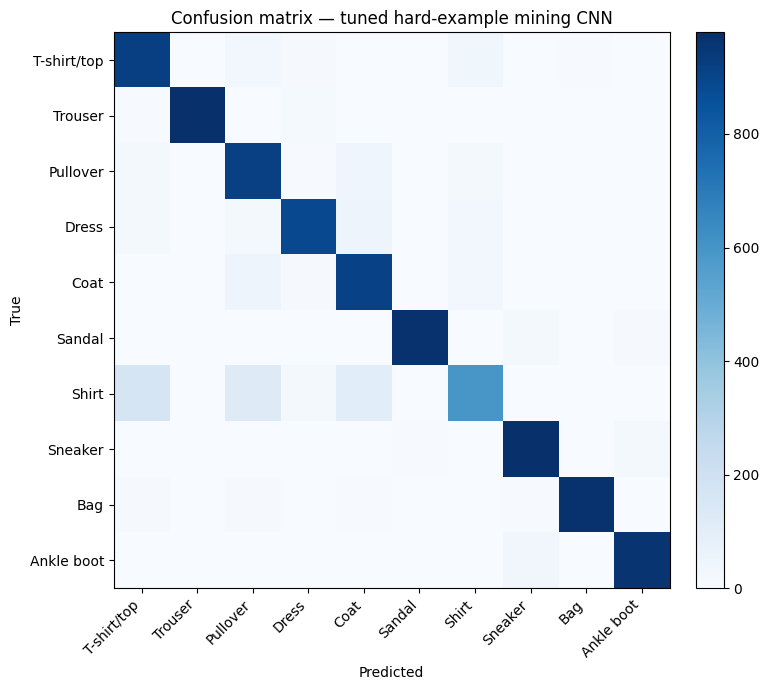

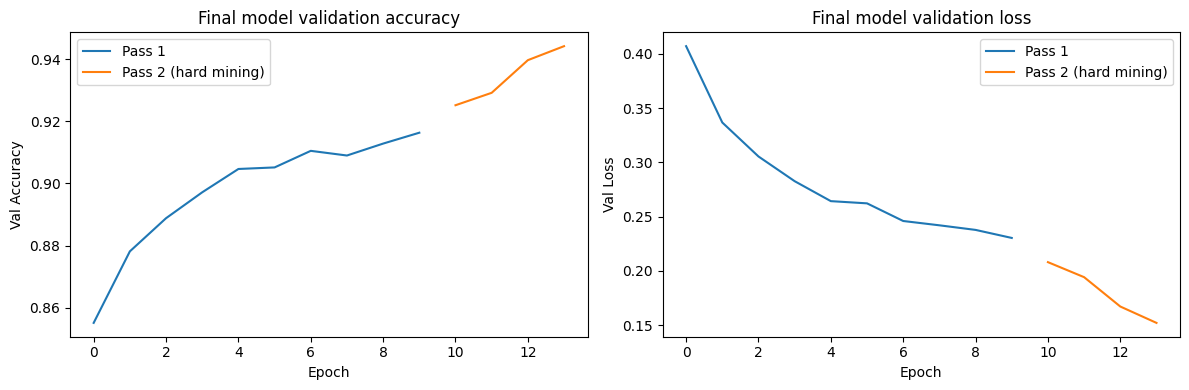

In [31]:
y_pred_final = np.argmax(final_model.predict(X_test_cnn, verbose=0), axis=1)
print(classification_report(y_test, y_pred_final, target_names=CLASS_NAMES))

cm_final = confusion_matrix(y_test, y_pred_final)
fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(cm_final, cmap="Blues")
ax.set_title("Confusion matrix — tuned hard-example mining CNN")
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_xticks(range(10))
ax.set_yticks(range(10))
ax.set_xticklabels(CLASS_NAMES, rotation=45, ha="right")
ax.set_yticklabels(CLASS_NAMES)
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(final_history_pass1.history["val_accuracy"], label="Pass 1")
if len(hard_idx_final) > 0:
    axes[0].plot(
        np.arange(len(final_history_pass1.history["val_accuracy"]),
                  len(final_history_pass1.history["val_accuracy"]) + len(final_history_pass2.history["val_accuracy"])),
        final_history_pass2.history["val_accuracy"],
        label="Pass 2 (hard mining)",
    )
axes[0].set_title("Final model validation accuracy")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Val Accuracy")
axes[0].legend()

axes[1].plot(final_history_pass1.history["val_loss"], label="Pass 1")
if len(hard_idx_final) > 0:
    axes[1].plot(
        np.arange(len(final_history_pass1.history["val_loss"]),
                  len(final_history_pass1.history["val_loss"]) + len(final_history_pass2.history["val_loss"])),
        final_history_pass2.history["val_loss"],
        label="Pass 2 (hard mining)",
    )
axes[1].set_title("Final model validation loss")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Val Loss")
axes[1].legend()

plt.tight_layout()
plt.show()

## 15. Analysis

### Starting point: baseline CNN

The baseline model Conv2D(32) → MaxPool → Dense(64) → Dense(10, Adam, 10 epochs) reached **91.21% test accuracy**. Training and validation curves tracked closely through most of training (final epoch: ~94.7% train accuracy vs ~91.3% validation accuracy), which suggests mild overfitting but nothing severe. The baseline already performed well on “easy” classes (Trouser, Sandal, Sneaker, Bag, Ankle boot near 97–100% precision/recall).

The main weakness showed up in the upper-body clothing classes, especially Shirt (recall ~0.71, F1 ~0.75). The confusion matrix confirmed that T-shirt/top, Pullover, Dress, Coat, and Shirt were frequently confused with each other — exactly the pattern EDA and per-class reports pointed to.

### One-factor-at-a-time experiments

I kept the baseline as a fixed reference and changed one thing per experiment so effects were easier to interpret.

| Experiment | Change | Test accuracy | vs baseline |
|---|---|---:|---|
| Baseline | — | 0.9121 | — |
| Exp 1: Augmented CNN | RandomFlip + RandomRotation | 0.8685 | −4.4 pp |
| Exp 2: Deeper CNN | Second conv block (64 filters) | 0.9062 | −0.6 pp |
| Exp 3: Hard-example mining | Upweight misclassified upper-body train examples | 0.9116 | −0.05 pp |

Experiment 1 (augmentation) hurt overall accuracy the most. Validation loss climbed much faster than training loss, which looks like the model struggled to learn stable features under augmentation on these small, centered 28×28 images. Augmentation can help on harder datasets, but here it added noise without enough benefit.

Experiment 2 (deeper architecture) added capacity but did not improve test accuracy. Training took longer per epoch and validation accuracy plateaued around the same level as the baseline — a sign that more depth alone was not the bottleneck.

Experiment 3 (hard-example mining) matched the baseline on a single run (91.16%) while targeting the classes that actually failed. That made it the most promising direction for a final model, even though the raw test-accuracy gain on one seed was tiny.

### Multi-seed stability (checking for a lucky split)

Because a single train/validation split can look better or worse by chance, I re-ran all four models across 5 seeds. Average test accuracy:

| Model | Mean acc | Std |
|---|---:|---:|
| Hard-example mining | 0.9060 | 0.0043 |
| Baseline | 0.8999 | 0.0022 |
| Deeper CNN | 0.8931 | 0.0053 |
| Augmented CNN | 0.8577 | 0.0040 |

Hard-example mining beat the baseline in 4 of 5 seeds (mean +0.61 pp) and had the best mean Shirt F1 (~0.737 vs ~0.718). That gave me more confidence that Experiment 3 was a real improvement, not a lucky initialization.

### Optuna tuning and final model

Optuna (20 trials, maximizing validation accuracy on a fixed 90/10 tuning split) selected a deeper architecture with dropout and a lower learning rate:

- 2 conv blocks (64 → 128 filters), dense 128, dropout ~0.26, lr ~2.5e-4, batch size 64, 4 pass-2 epochs, 2 hard-example copies

Best tuning validation accuracy: 92.52%.

After retraining with those hyperparameters on the full training set, the final test accuracy was 90.78% — slightly below both the baseline (91.21%) and the untuned hard-example model (91.16%). So Optuna improved validation performance but did not fully transfer to the held-out test set.

Where overfitting showed up:

1. Baseline / deeper models: training accuracy kept rising while validation accuracy flattened (~91–91.3%), a classic mild gap.
2. Augmented model: large validation loss increase and the clearest overfitting signal in the notebook.
3. Hard-example pass 2: when validation_split was applied to the duplicated dataset, validation accuracy collapsed (~0.31) even though test accuracy was fine. That was a methodological issue (validation indices no longer matched the original split), not necessarily bad generalization — and it motivated using a fixed validation set during tuning.
4. Optuna final model: validation accuracy reached ~94.4% during pass 2, but test accuracy stayed ~90.8%. The tuned model likely overfit the tuning validation split.

Per-class tradeoff on the final tuned model: upper-body recall improved for T-shirt/top, Pullover, and Coat (recall ~0.92 vs ~0.85–0.86 on the untuned hard model), but Shirt recall dropped to 0.59 (precision rose to 0.84). Overall accuracy stayed ~91%, but the error profile shifted. That is an important reminder that accuracy alone hides class-level tradeoffs.

What I learned

1. EDA mattered. Even though classes are balanced, EDA + confusion matrices showed the real problem was upper-body confusion, not global class imbalance. That directly motivated hard-example mining instead of generic fixes.
2. Simpler changes were easier to interpret than throwing augmentation and depth at the problem at the same time.
3. Hard-example mining was the best experimental direction even when single-run test accuracy looked similar to the baseline.
4. Optuna found a stronger validation model, but test performance did not improve, which suggests I should use more rigorous tuning validation (e.g., k-fold or a separate tuning holdout + final re-check) before calling a model “final.”
5. For Fashion MNIST a small baseline CNN is already strong some of the gains come from targeting the hard classes.

## 16. Personal workflow

### 1. Start with EDA 

For neural networks, I would always begin with EDA — not just to check shape and normalization, but to understand where the model is likely to fail. On this project, looking at sample images, pixel distributions, and (later) confusion matrices showed that:

- classes are balanced, so accuracy is a reasonable metric;
- most pixels are dark background, so scaling to [0, 1] is enough;
- the hard cases are visually similar upper-body classes, especially Shirt.

That EDA step saved time: instead of guessing, I could design Experiment 3 to target the actual error pattern.

### 2. Build a simple baseline and treat it as the reference

My first model would still be a small, boring CNNe. I would record baseline test metrics, confusion matrix, and train/val curves**, then use that run as the benchmark for every later experiment.

If a new idea cannot beat the baseline consistently, it is probably not worth tuning yet.

### 3. Change one factor at a time

When experimenting, I would keep architecture, optimizer, epochs, and data fixed unless I am deliberately testing one change. This assignment reinforced why:

- augmentation alone hurt;
- depth alone did not help much;
- hard-example mining — tied to an EDA finding — was the only change that improved multi-seed performance.

One-at-a-time experiments make cause and effect much clearer in the write-up and in my own head.

### 4. Check stability across seeds before trusting a winner

A single run can look good because of initialization or validation-split luck. I would run multiple seeds (or cross-validation if affordable) on the top 2–3 candidates and compare mean ± std. Here, hard-example mining won that check even when one-run test accuracy was nearly tied with the baseline.

### 5. Use systematic tuning (Optuna) on the best *idea*, not the biggest model

Once I have a promising approach — hard-example mining, in this case — I would use Optuna (or similar) to tune learning rate, batch size, depth, dropout, and training schedule. Lessons from this run:

- watch for validation–test gaps after tuning (my best val acc was 92.5% but test was 90.8%);
- add trial logging


### 6. Evaluate with metrics + curves, not one number

I would always report:

- test accuracy / loss;
- per-class precision/recall especially hard classes;
- confusion matrix;
- train vs validation curves for overfitting.

Overall accuracy hid the fact that my tuned model traded Shirt recall for precision.

### 7. What I would do differently next time

- Run EDA-driven error analysis earlier
- Keep the baseline minimal until a targeted experiment proves I need more capacity.
- During Optuna, track per-class F1 or a weighted metric for the classes I care about.

Overall my workflow is EDA → baseline → one-factor experiments → seed stability → Optuna on the winner → final test evaluation with curves and confusion matrices. The baseline is the anchor. EDA tells me what to change and seeds or cv and validation behavior tell me whether the improvement is real.